<a href="https://colab.research.google.com/github/SauHin/Pneumonia-Detection-VGG16/blob/main/PneuScanAI_ModelTrain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pneumonia Detection using Transfer Learning (VGG16)
Author: Jonathan Davin, Bryan Dale, Michael Hendrilie

In [3]:
# Mount Google Drive untuk dataset
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Extract file dataset
import zipfile
import os

zip_path = '/content/drive/MyDrive/AOL_AI/Pneumonia Detection Dataset.zip'

extract_path = '/content/'

if os.path.exists(zip_path):
    print(f"File ditemukan: {zip_path}")
    print("Sedang mengekstrak... (Mungkin memakan waktu 1-2 menit)")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Ekstraksi SELESAI! Silakan cek panel folder di kiri.")
else:
    print("ERROR: File tidak ditemukan! Pastikan path Anda benar.")

File ditemukan: /content/drive/MyDrive/AOL_AI/Pneumonia Detection Dataset.zip
Sedang mengekstrak... (Mungkin memakan waktu 1-2 menit)
Ekstraksi SELESAI! Silakan cek panel folder di kiri.


In [2]:
!pip install tensorflow keras scipy glob2

In [3]:
from keras.models import Model
from keras.layers import Flatten,Dense
from keras.applications.vgg16 import VGG16
import matplotlib.pyplot as plot
from glob import glob

In [4]:
IMAGESHAPE = [224, 224, 3]
training_data = 'chest_xray/train'
testing_data = 'chest_xray/test'

In [5]:
vgg_model = VGG16(input_shape=IMAGESHAPE, weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
for each_layer in vgg_model.layers:
	each_layer.trainable = False

In [7]:
classes = glob('chest_xray/train/*')

In [8]:
flatten_layer = Flatten()(vgg_model.output)
prediction = Dense(len(classes), activation='softmax')(flatten_layer)

In [9]:
final_model = Model(inputs=vgg_model.input, outputs=prediction)
final_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 0)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
final_model.compile(
loss='categorical_crossentropy',
optimizer='adam',
metrics=['accuracy']
)


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255,
								shear_range = 0.2,
								zoom_range = 0.2,
								horizontal_flip = True)
testing_datagen = ImageDataGenerator(rescale =1. / 255)

In [14]:
training_set = train_datagen.flow_from_directory('chest_xray/train',
												target_size = (224, 224),
												batch_size = 4,
												class_mode = 'categorical')


Found 5216 images belonging to 2 classes.


In [15]:
test_set = testing_datagen.flow_from_directory('chest_xray/test',
											target_size = (224, 224),
											batch_size = 4,
											class_mode = 'categorical')


Found 624 images belonging to 2 classes.


In [ ]:
fitted_model = final_model.fit(
training_set,
validation_data=test_set,
epochs=5,
steps_per_epoch=len(training_set),
validation_steps=len(test_set)
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 141s 104ms/step - accuracy: 0.8854 - loss: 0.3745 - val_accuracy: 0.9022 - val_loss: 0.5629
Epoch 2/5
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 130s 100ms/step - accuracy: 0.9480 - loss: 0.2030 - val_accuracy: 0.8686 - val_loss: 1.2664
Epoch 3/5
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 131s 100ms/step - accuracy: 0.9489 - loss: 0.2246 - val_accuracy: 0.9022 - val_loss: 0.7602
Epoch 4/5
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 129s 99ms/step - accuracy: 0.9571 - loss: 0.2019 - val_accuracy: 0.8798 - val_loss: 1.0751
Epoch 5/5
1304/1304 ━━━━━━━━━━━━━━━━━━━━ 129s 99ms/step - accuracy: 0.9590 - loss: 0.2135 - val_accuracy: 0.9038 - val_loss: 0.6745


In [ ]:
final_model.save('our_model.h5')

In [ ]:
import shutil

# Copy file dari Colab ke Google Drive
source = '/content/our_model.h5'
destination = '/content/drive/MyDrive/AOL_AI/model_pneumonia_vgg16.h5'

try:
    shutil.copy(source, destination)
    print("Sukses! Model berhasil diamankan di Google Drive Anda.")
    print("Nama file: model_pneumonia_vgg16.h5")
except Exception as e:
    print(f"Gagal menyalin: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 851ms/step


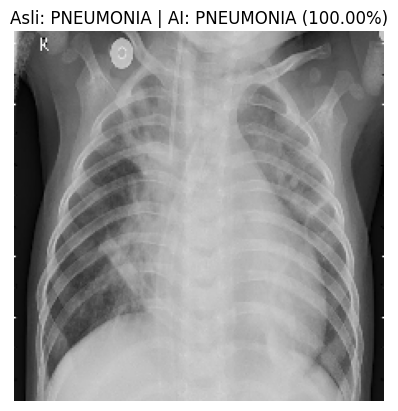

✅ BENAR


In [27]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
import random

# Load model
final_model = load_model('drive/MyDrive/AOL_AI/model_pneumonia_vgg16.h5')

class_map = {0: 'NORMAL', 1: 'PNEUMONIA'}

# Ambil gambar random
test_folder = '/content/chest_xray/test'
kategori_asli = random.choice(['PNEUMONIA', 'NORMAL'])
folder_kategori = os.path.join(test_folder, kategori_asli)
nama_file = random.choice(os.listdir(folder_kategori))
path_gambar = os.path.join(folder_kategori, nama_file)

# Preprocessing
img = image.load_img(path_gambar, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

img_data = x / 255.0

# Prediksi
prediction = final_model.predict(img_data)
hasil_probabilitas = prediction[0]

if hasil_probabilitas.size == 0:
    print("ERROR: Model mengembalikan prediksi kosong. Pastikan model dimuat dengan benar dan memiliki kelas output yang valid.")
    raise ValueError("Model returned empty predictions. Check model architecture or loaded file.")

index_prediksi = np.argmax(hasil_probabilitas)
label_prediksi = class_map[index_prediksi]
confidence = hasil_probabilitas[index_prediksi] * 100

# Output
plt.imshow(img)
plt.title(f"Asli: {kategori_asli} | AI: {label_prediksi} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

# Evaluasi
if kategori_asli == label_prediksi:
    print("✅ BENAR")
else:
    print("❌ SALAH")
    print(f"Detail Probabilitas: Normal={hasil_probabilitas[0]:.4f}, Pneumonia={hasil_probabilitas[1]:.4f}")

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import os

# Dataset untuk tes akurasi
test_dir = '/content/chest_xray/test'

# Load Model
if 'final_model' not in locals():
    if os.path.exists('drive/MyDrive/AOL_AI/model_pneumonia_vgg16.h5'):
        final_model = load_model('drive/MyDrive/AOL_AI/model_pneumonia_vgg16.h5')
    else:
        print("Error: File model  tidak ditemukan!")

eval_datagen = ImageDataGenerator(rescale=1./255)

if os.path.exists(test_dir):
    eval_generator = eval_datagen.flow_from_directory(
            test_dir,
            target_size=(224, 224),
            batch_size=32,
            class_mode='categorical',
            shuffle=False
    )

    # Hitung akurasi
    print("Sedang mengevaluasi seluruh dataset test...")
    results = final_model.evaluate(eval_generator)

    print("\n-------------------------------")
    print(f"Loss: {results[0]:.4f}")
    print(f"Akurasi Final pada Test Set: {results[1] * 100:.2f}%")
    print("-------------------------------")
else:
    print(f"Folder {test_dir} tidak ditemukan. Cek kembali struktur folder Anda.")

Found 624 images belonging to 2 classes.
Sedang mengevaluasi seluruh dataset test...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


20/20 ━━━━━━━━━━━━━━━━━━━━ 25s 575ms/step - accuracy: 0.8937 - loss: 0.7427

-------------------------------
Loss: 0.6745
Akurasi Final pada Test Set: 90.38%
-------------------------------


Sedang memprediksi 624 gambar... (Mohon tunggu)
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 322ms/step


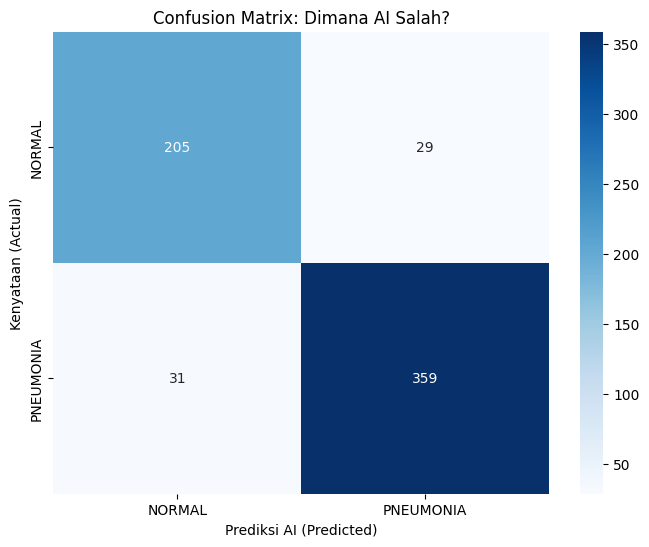


=== LAPORAN PERFORMA LENGKAP ===
              precision    recall  f1-score   support

      NORMAL       0.87      0.88      0.87       234
   PNEUMONIA       0.93      0.92      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.90      0.90       624
weighted avg       0.90      0.90      0.90       624



In [23]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

eval_generator.reset()

print("Sedang memprediksi 624 gambar... (Mohon tunggu)")
Y_pred = final_model.predict(eval_generator, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)

y_true = eval_generator.classes

cm = confusion_matrix(y_true, y_pred)
target_names = ['NORMAL', 'PNEUMONIA']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.ylabel('Kenyataan (Actual)')
plt.xlabel('Prediksi AI (Predicted)')
plt.title('Confusion Matrix: Dimana AI Salah?')
plt.show()

print("\n=== LAPORAN PERFORMA LENGKAP ===")
print(classification_report(y_true, y_pred, target_names=target_names))